In [1]:
# import libraries
import qiskit
from qiskit import QuantumCircuit,transpile

from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit.circuit.library import QFT
from qiskit.circuit import Parameter

from qiskit_aer.primitives import Sampler as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit.visualization import plot_histogram, plot_bloch_multivector


import matplotlib.pyplot as plt
import numpy as np 
from math import gcd 
from numpy.random import randint 
import pandas as pd 
from scipy.optimize import minimize

In [3]:
## C = 1, A, B = max(v_i,j)

def knapsack_hamiltonian(weights, values, capacities, gamma):
    weights = np.array(weights); values = np.array(values); capacities = np.array(capacities)

    maxv = 2 * np.max(values)
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 
    s = np.int64(np.floor(np.log2(capacities)) + 1) # number of slack bits 
    total_s = np.sum(s)

    qc = QuantumCircuit(n*m + total_s*m)

    for i in range(m): 
        b = np.array([_ for _ in range(s[i])])

        for j in range(n):
            # qubit i, j corresponds to i*n + j 
            # objective term 
            qc.rz(-gamma*values[i], i*n + j)

            # occupation term 1 
            qc.rz(maxv * gamma*(1-2*m), i*n + j)

            # all capacity terms 
            cap_linear_ij = -np.sum(weights*weights[j])/2 - np.sum(weights[j]*2**b[i])/2 + weights[j]*capacities[i]
            qc.rz(maxv * 2*cap_linear_ij*gamma, i*n + j)

            for jp in range(j+1, n): 
                if j != jp: 
                    qc.rzz(maxv * gamma*weights[j]*weights[jp]/2, i*n + j, i*n + jp)

            for ip in range(i+1, m): 
                # occupation term 2 
                if i != ip: 
                    qc.rzz(maxv * gamma/2, i*n + j, ip*n + j)

            for b_val in b: 
                qc.rzz(maxv * gamma*weights[j]*2**b_val, i*n + j, n*m + i*s[i] + b_val)
        
        for (i_b, b_val) in enumerate(b): 
            cap_linear_ib = -np.sum(2**(b_val+b[i]))/2 - np.sum(weights*2**b_val)/2 + 2**b_val*capacities[i]
            qc.rz(maxv * 2*cap_linear_ib*gamma, n*m + i*s[i] + b_val)

            for i_bp in range(i_b, len(b)):
                bp_val = b[i_bp]
                if b_val != bp_val: 
                    qc.rzz(maxv * 2**(b_val + bp_val)/2, n*m + i*s[i] + b_val, n*m + i*s[i] + bp_val)

    return qc 

In [4]:
def mixing_hamiltonian(N, beta): 
    qc = QuantumCircuit(N)
    
    for i in range(N): 
        qc.rx(2*beta, i)

    return qc 

In [ ]:
def full_knapsack_circuit(weights, values, capacities, p): 
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 
    s = np.int64(np.floor(np.log2(capacities)) + 1) # number of slack bits 
    total_s = np.sum(s)
    N = n*m + total_s

    qc = QuantumCircuit(N, n*m)
    qc.h(range(N))

    for _ in range(p): 
        qc.compose(knapsack_hamiltonian(weights, values, capacities, Parameter(f"γ{_}")), inplace=True)
        qc.barrier()
        qc.compose(mixing_hamiltonian(N, Parameter(f"β{_}")), inplace=True)
        qc.barrier()

    qc.measure(range(n*m), range(n*m))
    return qc 

In [81]:
def objective(params, weights, values, capacities, p, sampler, shots=10000): 
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 

    qc = full_knapsack_circuit(weights, values, capacities, p)
    job = sampler.run([qc], [params], shots=shots)
    counts = job.result().quasi_dists[0].binary_probabilities()

    # compute expected value 
    expected = 0 
    for bitstring, prob in counts.items(): 
        # get all the items that were chosen 
        x = np.array([int(b) for b in reversed(bitstring)])

        assert len(x) == n*m, f"expected {n*m} bits, got {len(x)}"

        x = x.reshape(m, n)
        if all(np.dot(x[i], weights) <= capacities[i] for i in range(m)): 
            # i.e., if feasible 
            total_value = sum(x[i][j] * values[j] for i in range(m) for j in range(n))
            expected += prob * total_value
    
    return -expected # minimize -expected to maximize knapsack value 

In [ ]:
def run_knapsack(weights, values, capacities, sampler, p=1):
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 

    best_value = 0
    best_bitstring = None
    for _ in range(1):
        result = minimize(objective, x0=np.random.uniform(0, np.pi, 2*p), args=(weights, values, capacities, p, sampler, 8192), method='COBYLA', options={'maxiter': 500})

        # now run with optimized params
        best_params = result.x

        mycirc = full_knapsack_circuit(weights, values, capacities, p)

        job_sim = sampler.run([mycirc], [best_params], shots=4096)

        quasi_dists = job_sim.result().quasi_dists[0].binary_probabilities()

        # check feasible out of most probable
        sorted_results = sorted(quasi_dists.items(), key=lambda x: x[1], reverse=True)
        soln = []
        soln_value = 0

        for bitstring, prob in sorted_results: 
            # get all the items that were chosen 
            x = np.array([int(b) for b in reversed(bitstring)])

            assert len(x) == n*m, f"expected {n*m} bits, got {len(x)}"

            x = x.reshape(m, n)
            if all(np.dot(x[i], weights) <= capacities[i] for i in range(m)): 
                soln = x
                soln_value = np.sum(np.array([np.dot(x[i], values) for i in range(m)]))
                break 
        
        if soln_value > best_value: 
            best_value = soln_value
            best_bitstring = soln 
        
    return best_bitstring, best_value


In [13]:
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

sampler = AerSampler()

In [14]:
capacities = [7]
p = 2 # number of layers 
# 10 = 1010
weights = [1, 1, 6, 3]
values = [1, 3, 8, 10]
n = len(weights) # number of items 
m = len(capacities) # number of knapsacks 


In [42]:
result, result_value = run_knapsack(weights, values, capacities, sampler, p)
print(result, result_value)

14 [[1 1 0 1]]


In [35]:
from itertools import product

def brute_force_multiknapsack(weights, values, capacities):
    n = len(weights)  # number of items
    m = len(capacities)  # number of knapsacks

    best_value = 0
    best_x = None

    # x[i][j] = 1 if item j is in knapsack i
    for x in product([0,1], repeat=n*m):
        x = np.array(x).reshape(m, n)
        
        # each item can only be in one knapsack
        if np.any(x.sum(axis=0) > 1):
            continue
        
        # check capacity constraint for each knapsack
        if np.all(x @ weights <= capacities):
            val = np.sum(x * values)
            if val > best_value:
                best_value = val
                best_x = x

    return best_x, best_value

In [51]:
##### ------- CHECKING CORRECTNESS --------- #####

p = 2 # number of layers 

test_cases = [
    # (weights, values, capacities, expected_value, description)
    
    # trivial - take everything
    ([1, 1, 1], [3, 2, 1], [10], 6, "all items fit"),
    
    # trivial - take nothing
    ([10, 10], [5, 5], [1], 0, "nothing fits"),
    
    # obvious best item
    ([1, 9], [10, 1], [9], 10, "take the light high value item"),
    
    # tight capacity - must choose
    ([5, 6], [4, 5], [9], 5, "only one item fits, take higher value"),
    
    # greedy trap - best ratio is not best solution
    ([3, 4, 5], [4, 5, 6], [8], 10, "greedy by ratio fails here"),

    # exactly fills capacity
    ([3, 5], [4, 7], [8], 11, "both items exactly fill capacity"),
    
    # single item
    ([3], [5], [3], 5, "single item fits"),
    ([3], [5], [2], 0, "single item doesnt fit"),
]

for weights, values, capacities, expected, desc in test_cases:
    x, val = brute_force_multiknapsack(
        np.array(weights), np.array(values), np.array(capacities)
    )
    _, qaoa_val = run_knapsack(weights, values, capacities, sampler, p)  
    
    bf_correct = val == expected
    qaoa_correct = qaoa_val == expected
    print(f"{desc}")
    print(f"  expected: {expected}, brute force: {val} ({'✓' if bf_correct else '✗'}), qaoa: {qaoa_val} ({'✓' if qaoa_correct else '✗'})")

all items fit
  expected: 6, brute force: 6 (✓), qaoa: 6 (✓)
nothing fits
  expected: 0, brute force: 0 (✓), qaoa: 0 (✓)
take the light high value item
  expected: 10, brute force: 10 (✓), qaoa: 10 (✓)
only one item fits, take higher value
  expected: 5, brute force: 5 (✓), qaoa: 5 (✓)
greedy by ratio fails here
  expected: 10, brute force: 10 (✓), qaoa: 10 (✓)
both items exactly fill capacity
  expected: 11, brute force: 11 (✓), qaoa: 11 (✓)
single item fits
  expected: 5, brute force: 5 (✓), qaoa: 5 (✓)
single item doesnt fit
  expected: 0, brute force: 0 (✓), qaoa: 0 (✓)


In [46]:
import time

In [103]:
# in general, let us use the (ratio = quantum solution / bruteforce solution) to benchmark 
##### ------- CHECKING DEPENDENCE ON SIZE --------- #####
sizes = [3, 4, 5, 6, 7]
cl_times = []
q_times = []
accuracy = []
for n in sizes:
    weights = np.random.randint(1, 10, n)
    values = np.random.randint(1, 10, n)
    capacities = np.random.randint(1, 10, 1)

    start_quantum = time.time()
    _, qaoa_val = run_knapsack(weights, values, capacities, sampler, p)  
    q_times.append(time.time() - start_quantum)

    start_classical = time.time()
    _, val = brute_force_multiknapsack(np.array(weights), np.array(values), np.array(capacities))
    cl_times.append(time.time() - start_classical) 

    if qaoa_val > val: 
        accuracy.append(2)
    else: 
        accuracy.append(qaoa_val / val if val != 0 else 1) 

    # run and record time + 
    #     Runtime vs n (number of items)
    # Approximation ratio vs n
    # Number of optimizer iterations needed to converge


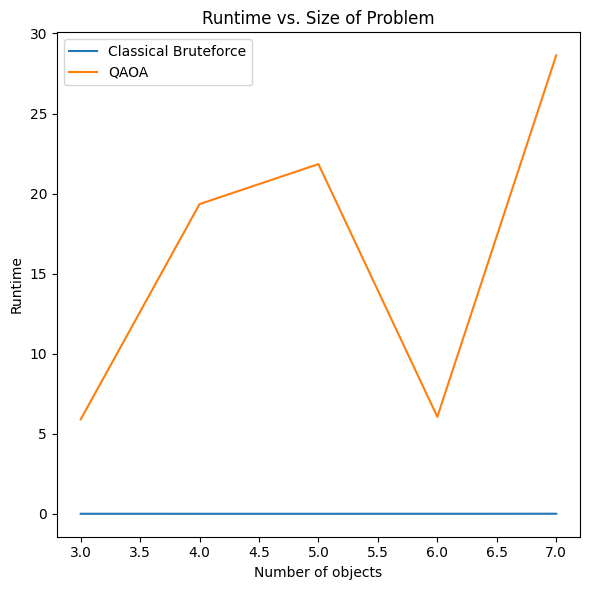

In [104]:
plt.figure(figsize=(6, 6), layout="tight")
plt.plot(sizes, cl_times, label="Classical Bruteforce")
plt.plot(sizes, q_times, label="QAOA")
plt.xlabel("Number of objects")
plt.ylabel("Runtime")
plt.legend()
plt.title("Runtime vs. Size of Problem")
plt.show()

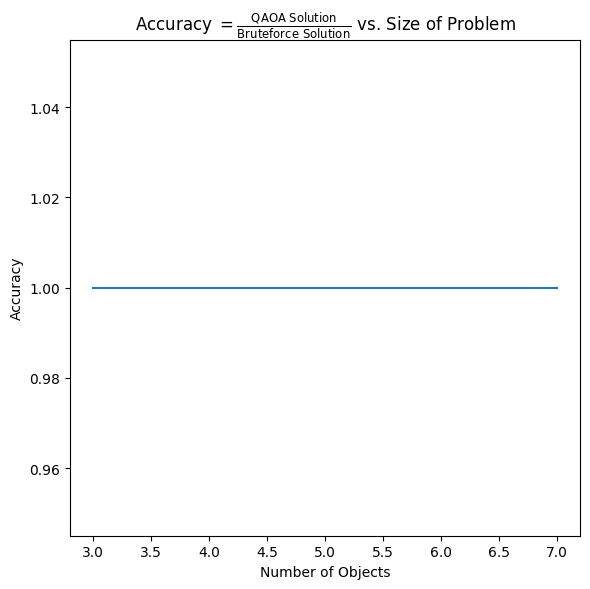

In [105]:
plt.figure(figsize=(6, 6), layout="tight")
plt.plot(sizes, accuracy)
plt.xlabel("Number of Objects")
plt.ylabel(r"Accuracy")
plt.title(r"Accuracy $= \frac{\text{QAOA Solution}}{\text{Bruteforce Solution}}$ vs. Size of Problem")
plt.show()

In [100]:
##### ------- CHECKING DEPENDENCE ON SIZE --------- #####
# now check how long it takes for the optimizer to converge

history = []
conv_steps = []
def callback(params):
    history.append(params.copy())

for n in sizes: 
    sum_history = 0 
    for _ in range(10): 
        weights = np.random.randint(1, 10, n)
        values = np.random.randint(1, 10, n)
        capacities = np.random.randint(1, 10, 1)

        result = minimize(objective, x0=np.random.uniform(0, np.pi, 2*p), args=(weights, values, capacities, p, sampler, 8192), method='COBYLA', callback=callback, options={'maxiter': 500})
        sum_history += len(history)
        history = []
    conv_steps.append(sum_history/10)

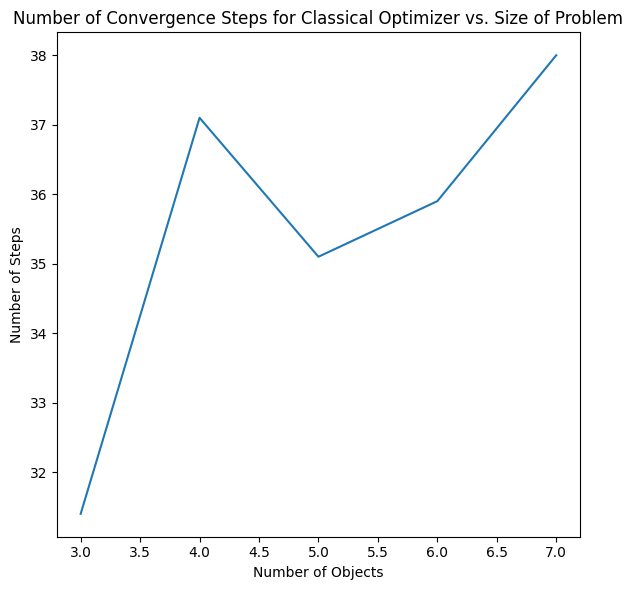

In [101]:
plt.figure(figsize=(6, 6), layout="tight")
plt.plot(sizes, conv_steps)
plt.xlabel("Number of Objects")
plt.ylabel(r"Number of Steps")
plt.title(r"Number of Convergence Steps for Classical Optimizer vs. Size of Problem")
plt.show()

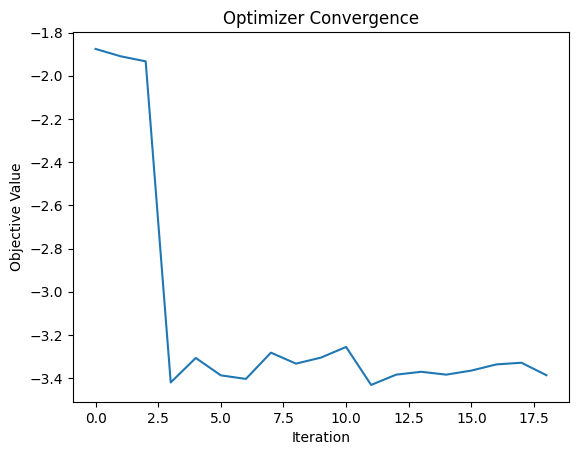

In [80]:
######### CHECKING CONVERGENCE OF CLASSICAL OPTIMIZER 
n = 5 
m = 1 
p = 2 
history = []
def callback(params):
    history.append(params.copy())

weights = np.random.randint(1, 10, n)
values = np.random.randint(1, 10, n)
capacities = np.random.randint(1, 10, m)

result = minimize(objective, x0=np.random.uniform(0, np.pi, 2*p), args=(weights, values, capacities, p, sampler, 8192), method='COBYLA', callback=callback, options={'maxiter': 500})

obj_history = [objective(h, weights, values, capacities, p, sampler) for h in history]

plt.plot(range(len(history)), obj_history)
plt.xlabel('Iteration')
plt.ylabel('Objective Value')
plt.title('Optimizer Convergence')
plt.show()

In [112]:
##### ------- CHECKING DEPENDENCE ON NUMBER OF LAYERS --------- #####

cl_times = []
q_times = []
accuracy = []
n = 8
for p in range(1, 10):
    weights = np.random.randint(1, 5, n)
    values = np.random.randint(1, 5, n)
    capacities = np.random.randint(1, 10, 1)

    start_quantum = time.time()
    _, qaoa_val = run_knapsack(weights, values, capacities, sampler, p)  
    q_times.append(time.time() - start_quantum)

    start_classical = time.time()
    _, val = brute_force_multiknapsack(np.array(weights), np.array(values), np.array(capacities))
    cl_times.append(time.time() - start_classical) 

    accuracy.append(qaoa_val / val if val != 0 else 1) 



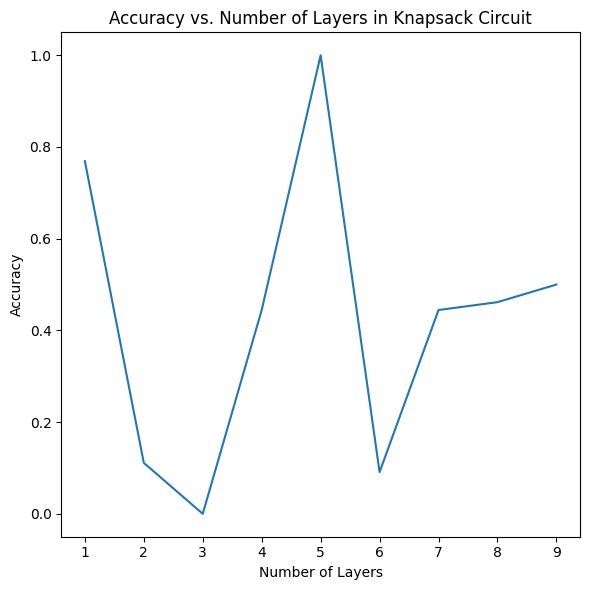

In [113]:
plt.figure(figsize=(6, 6), layout="tight")
plt.plot(range(1, 10), accuracy)
plt.xlabel("Number of Layers")
plt.ylabel(r"Accuracy")
plt.title(r"Accuracy vs. Number of Layers in Knapsack Circuit")
plt.show()

In [114]:
## SENSITIVITY TO INITIAL CONDITIONS 

n = 7  
weights = np.random.randint(1, 5, n)
values = np.random.randint(1, 5, n)
capacities = np.random.randint(1, 10, 1)

best_value = 0
best_bitstring = None
results = []
for _ in range(5):
    result = minimize(objective, x0=np.random.uniform(0, np.pi, 2*p), args=(weights, values, capacities, p, sampler, 8192), method='COBYLA', options={'maxiter': 500})

    # now run with optimized params
    best_params = result.x

    mycirc = full_knapsack_circuit(weights, values, capacities, p)

    job_sim = sampler.run([mycirc], [best_params], shots=4096)

    quasi_dists = job_sim.result().quasi_dists[0].binary_probabilities()

    # check feasible out of most probable
    sorted_results = sorted(quasi_dists.items(), key=lambda x: x[1], reverse=True)
    soln = []
    soln_value = 0

    for bitstring, prob in sorted_results: 
        # get all the items that were chosen 
        x = np.array([int(b) for b in reversed(bitstring)])

        assert len(x) == n*m, f"expected {n*m} bits, got {len(x)}"

        x = x.reshape(m, n)
        if all(np.dot(x[i], weights) <= capacities[i] for i in range(m)): 
            soln = x
            soln_value = np.sum(np.array([np.dot(x[i], values) for i in range(m)]))
            break 
    
    if soln_value > best_value: 
        best_value = soln_value

    results.append(best_value)
    best_value = 0

print(results) 

[np.int64(1), 0, np.int64(4), np.int64(1), np.int64(4)]


In [116]:
accuracy = np.array(results)/brute_force_multiknapsack(weights, values, capacities)[1]
print(accuracy)
accuracy.mean()


[0.25 0.   1.   0.25 1.  ]


np.float64(0.5)